## Installing

In [ ]:
!git clone https://github.com/DependableSystemsLab/SolidiFI-benchmark.git
!git clone https://github.com/smartbugs/smartbugs-curated.git
!git clone https://github.com/wuhongjun15/Peculiar.git
!git clone https://github.com/MRdoulestar/DeeSCVHunter.git
!git clone https://github.com/smartbugs/smartbugs-wild.git

fatal: destination path 'SolidiFI-benchmark' already exists and is not an empty directory.
fatal: destination path 'smartbugs-curated' already exists and is not an empty directory.
fatal: destination path 'Peculiar' already exists and is not an empty directory.
fatal: destination path 'DeeSCVHunter' already exists and is not an empty directory.
fatal: destination path 'smartbugs-wild' already exists and is not an empty directory.


In [ ]:
!git clone https://github.com/MANDO-Project/ge-sc

fatal: destination path 'ge-sc' already exists and is not an empty directory.


In [ ]:
import re
import random
import os
random.seed(42)

# Keywords of Solidity; immutable set
keywords = frozenset({
    'bool', 'break', 'case', 'catch', 'const', 'continue', 'default', 'do', 'double', 'struct',
    'else', 'enum', 'payable', 'function', 'modifier', 'emit', 'export', 'extern', 'false', 'constructor',
    'float', 'if', 'contract', 'int', 'long', 'string', 'super', 'or', 'private', 'protected', 'noReentrancy',
    'public', 'return', 'returns', 'assert', 'event', 'indexed', 'using', 'require', 'uint', 'onlyDaoChallenge',
    'transfer', 'Transfer', 'Transaction', 'switch', 'pure', 'view', 'this', 'throw', 'true', 'try', 'revert',
    'bytes', 'bytes4', 'bytes32', 'internal', 'external', 'union', 'constant', 'while', 'for', 'notExecuted',
    'NULL', 'uint256', 'uint128', 'uint8', 'uint16', 'address', 'call', 'msg', 'value', 'sender', 'notConfirmed',
    'private', 'onlyOwner', 'internal', 'onlyGovernor', 'onlyCommittee', 'onlyAdmin', 'onlyPlayers', 'ownerExists',
    'onlyManager', 'onlyHuman', 'only_owner', 'onlyCongressMembers', 'preventReentry', 'noEther', 'onlyMembers',
    'onlyProxyOwner', 'confirmed', 'mapping', 'solidity'
})

global_vars = frozenset({
    'block.timestamp', 'now', 'msg.sender', 'msg.value', 'block.number', 'block.difficulty',
    'block.coinbase', 'block.gaslimit', 'tx.origin', 'tx.gasprice', 'gasleft', 'this', 'super'
})

# Known non-user-defined functions; immutable set
main_set = frozenset({'function', 'constructor', 'modifier', 'contract'})
main_args = frozenset({'argc', 'argv'})

def clean_fragment(fragment):
    fun_symbols = {}
    var_symbols = {}
    fun_count = 1
    var_count = 1

    rx_fun = re.compile(r'\b([_A-Za-z]\w*)\b(?=\s*\()')
    rx_var = re.compile(r'\b([_A-Za-z]\w*)\b(?:(?=\s*\w+\()|(?!\s*\w+))(?!\s*\()')

    cleaned_fragment = []

    for line in fragment:
        # Skip lines that are comments (single-line or multi-line)
        if line.strip().startswith('//') or line.strip().startswith('/*') or line.strip().endswith('*/'):
            cleaned_fragment.append(line)
            continue

        # Remove string literals and non-ASCII chars from the code part
        nostrlit_line = re.sub(r'".*?"', '""', line)
        nocharlit_line = re.sub(r"'.*?'", "''", nostrlit_line)
        ascii_line = re.sub(r'[^\x00-\x7f]', '', nocharlit_line)

        # Process function and variable names
        user_fun = rx_fun.findall(ascii_line)
        user_var = rx_var.findall(ascii_line)

        for fun_name in user_fun:
            if fun_name not in main_set and fun_name not in keywords:
                if fun_name not in fun_symbols:
                    fun_symbols[fun_name] = f'FUN{fun_count}'
                    fun_count += 1
                ascii_line = re.sub(r'\b' + fun_name + r'\b(?=\s*\()', fun_symbols[fun_name], ascii_line)

        for var_name in user_var:
            if var_name not in keywords and var_name not in main_args and var_name not in global_vars:
                if var_name not in var_symbols:
                    var_symbols[var_name] = f'VAR{var_count}'
                    var_count += 1
                ascii_line = re.sub(r'\b' + var_name + r'\b(?:(?=\s*\w+\()|(?!\s*\w+))(?!\s*\()', var_symbols[var_name], ascii_line)

        cleaned_fragment.append(ascii_line)

    return cleaned_fragment

def remove_comments(solidity_code):
    # Regex patterns to match single-line and multi-line comments
    single_line_comment_pattern = r"//.*?(?=\n|$)"
    multi_line_comment_pattern = r"/\*.*?\*/"

    # Remove single-line comments
    code_without_single_line_comments = re.sub(single_line_comment_pattern, '', solidity_code, flags=re.DOTALL)

    # Remove multi-line comments
    cleaned_code = re.sub(multi_line_comment_pattern, '', code_without_single_line_comments, flags=re.DOTALL)

    return cleaned_code.strip()

def clean_code_formatting(code):
    # Split code into lines
    lines = code.split('\n')

    cleaned_lines = []
    for line in lines:
        # Remove trailing whitespace
        line = line.rstrip()

        # Skip empty lines (preserve newlines with content)
        if not line.strip():
            continue

        # Collapse multiple spaces/tabs (except in string literals)
        line = re.sub(r'(?<!")\s{2,}(?!")', ' ', line)

        cleaned_lines.append(line)

    # Join lines while preserving single newlines
    return '\n'.join(cleaned_lines)

In [ ]:
def seed_everything(seed: int):
    # Hàm đặt seed cố định cho tất cả các thư viện để kết quả có thể tái tạo lại được
    import random, os
    import numpy as np
    import torch

    random.seed(seed)  # Cố định seed cho thư viện random
    # os.environ['PYTHONHASHSEED'] = str(seed)  # Cố định hash seed của Python
    np.random.seed(seed)  # Cố định seed cho NumPy
    torch.manual_seed(seed)  # Cố định seed cho PyTorch CPU
    torch.cuda.manual_seed(seed)  # Cố định seed cho PyTorch GPU
    torch.backends.cudnn.deterministic = True  # Đảm bảo tính nhất quán của thuật toán cuDNN
    torch.backends.cudnn.benchmark = True  # Tối ưu hóa tốc độ tính toán

In [ ]:
seed_everything(42)

## SolidiFI-Benchmark

In [ ]:
import os

root = "/content/SolidiFI-benchmark/buggy_contracts"
vulnerabilities = os.listdir(root)
solidiFI_files =  {}
for vulnerability in vulnerabilities:
  solidiFI_files[vulnerability] = {}

for vulnerability in vulnerabilities:
    for file in os.listdir(f"{root}/{vulnerability}"):
        if file.endswith(".sol"):
            sol_code = open(f"{root}/{vulnerability}/{file}", "r").readlines()
            sol_code = "\n".join(sol_code)
            file_name = file.split(".")[0]
            solidiFI_files[vulnerability][file_name] = sol_code

In [ ]:
for vulnerability in vulnerabilities:
    tmp = [solidiFI_files[vulnerability][i] for i in solidiFI_files[vulnerability].keys()]
    print(f"Number of source code with {vulnerability}", len(set(tmp)))

Number of source code with TOD 49
Number of source code with Unhandled-Exceptions 49
Number of source code with Overflow-Underflow 49
Number of source code with tx.origin 49
Number of source code with Re-entrancy 49
Number of source code with Unchecked-Send 49
Number of source code with Timestamp-Dependency 49


In [ ]:
print(clean_code_formatting(remove_comments(solidiFI_files["Timestamp-Dependency"]["buggy_21"])))

pragma solidity ^0.5.11;
contract Token {
 function transfer(address to, uint256 value) public returns (bool success);
address winner_tmstmp7;
function play_tmstmp7(uint startTime) public {
	uint _vtime = block.timestamp;
	if (startTime + (5 * 1 days) == _vtime){
 winner_tmstmp7 = msg.sender;}}
 function transferFrom(address from, address to, uint256 value) public returns (bool success);
address winner_tmstmp23;
function play_tmstmp23(uint startTime) public {
	uint _vtime = block.timestamp;
	if (startTime + (5 * 1 days) == _vtime){
 winner_tmstmp23 = msg.sender;}}
 function balanceOf(address account) external view returns(uint256);
address winner_tmstmp14;
function play_tmstmp14(uint startTime) public {
	if (startTime + (5 * 1 days) == block.timestamp){
 winner_tmstmp14 = msg.sender;}}
 function allowance(address _owner, address _spender)external view returns(uint256);
address winner_tmstmp30;
function play_tmstmp30(uint startTime) public {
	if (startTime + (5 * 1 days) == block.timest

In [ ]:
import re
import pandas as pd

def find_function(lines, error_line):
    function_pattern = re.compile(r'\bfunction\s+\w+\s*\([^)]*\)\s*(\{[^}]*\})?')
    modifier_pattern = re.compile(r'\bmodifier\s+\w+\s*\([^)]*\)\s*(\{[^}]*\})?')
    constructor_pattern = re.compile(r'\bconstructor\s*\([^)]*\)\s*(\{[^}]*\})?')
    start_line = None

    # Search backward for the start of the function
    for i in range(error_line - 1, -1, -1):
        if function_pattern.search(lines[i]) or modifier_pattern.search(lines[i]) or constructor_pattern.search(lines[i]):
            start_line = i
            break

    if start_line is None:
        raise Exception("Function definition not found.")

    # Search forward for the end of the function
    end_line = None
    brace_count = 0
    in_function = False

    for i in range(start_line, len(lines)):
        line = lines[i]
        brace_count += line.count('{')
        brace_count -= line.count('}')

        if brace_count > 0:
            in_function = True
        elif brace_count == 0 and in_function:
            end_line = i
            break

    if end_line is None:
        raise Exception("Function end not found.")

    # Extract the function code
    function_code = "".join(lines[start_line:end_line + 1])
    return function_code


solidiFI_funcs =  {}
for vulnerability in vulnerabilities:
    solidiFI_funcs[vulnerability] = {
        "vulnerable": [],
        "non-vulnerable": []
    }


for vulnerability in vulnerabilities:
    for name, file in solidiFI_files[vulnerability].items():
        lines = file.splitlines(keepends=True)
        file_num = name[6:]
        csv_path = f"/content/SolidiFI-benchmark/buggy_contracts/{vulnerability}/BugLog_{file_num}.csv"
        tdf = pd.read_csv(csv_path)
        vul_line_num = list(tdf['loc'])

        vul_funcs = []
        all_funcs = []

        for line in range(len(lines)):
            try:
                func = find_function(lines, line)
                if "contract" not in func:
                    func = remove_comments(func).replace("\n\n\n\n\n", "\n").replace("\n\n\n\n", "\n").replace("\n\n\n", "\n").replace("\n\n", "\n")
                    all_funcs.append(func.strip())
            except:
                pass
        for er_line in vul_line_num:
            try:
                func = find_function(lines, er_line)
                if file_num == "21" and vulnerability == "Timestamp-Dependency":
                    print(func)
                    print("-" * 100)
                if "contract" not in func:
                    func = remove_comments(func).replace("\n\n\n\n\n", "\n").replace("\n\n\n\n", "\n").replace("\n\n\n", "\n").replace("\n\n", "\n")
                    vul_funcs.append(func.strip())
            except:
                pass

        vul_funcs = list(set(vul_funcs))
        all_funcs = list(set(all_funcs) - set(vul_funcs))
        solidiFI_funcs[vulnerability]["vulnerable"].extend(vul_funcs)
        solidiFI_funcs[vulnerability]["non-vulnerable"].extend(all_funcs)

      function mul(uint256 a, uint256 b) internal pure returns (uint256) 

    {

        if (a == 0) {

        return 0;}

        uint256 c = a * b;

        assert(c / a == b);

        return c;

    }

----------------------------------------------------------------------------------------------------
  function bug_tmstmp25() view public returns (bool) {

    return block.timestamp >= 1546300800;

  }

----------------------------------------------------------------------------------------------------
function bug_tmstmp40 () public payable {

	uint pastBlockTime_tmstmp40; // Forces one bet per block

	require(msg.value == 10 ether); // must send 10 ether to play

        require(now != pastBlockTime_tmstmp40); // only 1 transaction per block   //bug

        pastBlockTime_tmstmp40 = now;       //bug

        if(now % 15 == 0) { // winner    //bug

            msg.sender.transfer(address(this).balance);

        }

    }

---------------------------------------------------------

In [ ]:
for vulnerability in vulnerabilities:
  print(f"Number of vulnerable functions with {vulnerability}", len(solidiFI_funcs[vulnerability]["vulnerable"]))
  print(f"Number of non-vulnerable functions with {vulnerability}", len(solidiFI_funcs[vulnerability]["non-vulnerable"]))
  print("-" * 100)

Number of vulnerable functions with TOD 1163
Number of non-vulnerable functions with TOD 2462
----------------------------------------------------------------------------------------------------
Number of vulnerable functions with Unhandled-Exceptions 814
Number of non-vulnerable functions with Unhandled-Exceptions 1483
----------------------------------------------------------------------------------------------------
Number of vulnerable functions with Overflow-Underflow 874
Number of non-vulnerable functions with Overflow-Underflow 1716
----------------------------------------------------------------------------------------------------
Number of vulnerable functions with tx.origin 794
Number of non-vulnerable functions with tx.origin 1494
----------------------------------------------------------------------------------------------------
Number of vulnerable functions with Re-entrancy 773
Number of non-vulnerable functions with Re-entrancy 1297
--------------------------------------

In [ ]:
print(clean_code_formatting(solidiFI_funcs["Timestamp-Dependency"]["vulnerable"][20]))
cnt = 0
for function in solidiFI_funcs["Timestamp-Dependency"]["vulnerable"]:
    if "block.timestamp" in function:
        cnt += 1

print(cnt)

function bug_tmstmp28 () public payable {
	uint pastBlockTime_tmstmp28;
	require(msg.value == 10 ether);
 require(now != pastBlockTime_tmstmp28);
 pastBlockTime_tmstmp28 = now;
 if(now % 15 == 0) {
 msg.sender.transfer(address(this).balance);
 }
 }
359


In [ ]:
cnt = 0
for function in solidiFI_funcs["Re-entrancy"]["vulnerable"]:
    if "call.value" in function:
        cnt += 1

print(cnt)

124


## SmartBugs_Curated

In [ ]:
import json

with open("/content/smartbugs-curated/vulnerabilities.json") as f:
    data = json.load(f)

smartbugs_files, smartbugs_functions = {}, {}

for file_dis in data:
    vulnerability = file_dis["path"].split("/")[1]
    file_name = file_dis["path"].split("/")[-1]
    file_name = file_name.split(".")[0]
    if vulnerability not in smartbugs_files:
        smartbugs_files[vulnerability] = {}
        smartbugs_functions[vulnerability] = {
            "vulnerable": [],
            "non-vulnerable": []
        }
    with open(f"/content/smartbugs-curated/{file_dis['path']}", "r") as f:
        code = f.read()
    ok = 0
    lines = code.splitlines(keepends=True)
    # code = "\n".join(lines)
    code = remove_comments(code)
    for er_line in file_dis["vulnerabilities"]:
        try:
            func = find_function(lines, er_line["lines"][0])
            if vulnerability == "reentrancy":
                if "call.value" in func:
                    ok = 1
            elif vulnerability == "time_manipulation":
                if "now" in func or "block.timestamp" in func:
                    ok = 1
            if ok == 1:
                smartbugs_functions[vulnerability]["vulnerable"].append(remove_comments(func).strip())
                # print(remove_comments(func).strip() in code)
        except Exception as e:
            print(e)
            pass
    if ok == 1:
        smartbugs_files[vulnerability][code] = file_name

Function definition not found.
Function definition not found.


In [ ]:
for vulnerability in smartbugs_files.keys():
    tmp_cnt = {}
    if vulnerability == "reentrancy" or vulnerability == "time_manipulation":
        # print(f"Number of source code with {vulnerability} before", len(smartbugs_files[vulnerability]))
        print(f"Number of vulnerable functions with {vulnerability} before", len(smartbugs_functions[vulnerability]["vulnerable"]))
        print("-" * 100)
        cnt_more_than_one_content = []
        for file_content in smartbugs_functions[vulnerability]["vulnerable"]:
            if file_content not in tmp_cnt:
                tmp_cnt[file_content] = 1
            else:
                tmp_cnt[file_content] += 1

        for file_content in smartbugs_functions[vulnerability]["vulnerable"]:
            if tmp_cnt[file_content] > 1:
                cnt_more_than_one_content.append(file_content)

        print(f"Ratio of diff functions appear more than 1 with number of diff functions with {vulnerability} before", len(cnt_more_than_one_content) / len(smartbugs_functions[vulnerability]["vulnerable"]) * 100)
        print("-" * 100)
    # smartbugs_functions[vulnerability]["vulnerable"] = list(set(smartbugs_functions[vulnerability]["vulnerable"]))
    # if vulnerability == "reentrancy" or vulnerability == "time_manipulation":
    #     # print(f"Number of source code with {vulnerability} after", len(smartbugs_files[vulnerability]))
    #     print(f"Number of vulnerable functions with {vulnerability} after", len(smartbugs_functions[vulnerability]["vulnerable"]))
    #     print("-" * 100)

Number of vulnerable functions with reentrancy before 28
----------------------------------------------------------------------------------------------------
Ratio of diff functions appear more than 1 with number of diff functions with reentrancy before 67.85714285714286
----------------------------------------------------------------------------------------------------
Number of vulnerable functions with time_manipulation before 7
----------------------------------------------------------------------------------------------------
Ratio of diff functions appear more than 1 with number of diff functions with time_manipulation before 28.57142857142857
----------------------------------------------------------------------------------------------------


In [ ]:
import random
from collections import defaultdict

print("#" * 30 + " SmartBugs-Curated Ratios " + "#" * 30)

SmartBugs_ratio = []

# Duyệt qua các loại lỗ hổng trong smartbugs_functions
for vulnerability in smartbugs_functions.keys():
    if vulnerability in ["reentrancy", "time_manipulation"]:
        print(f"\n--- {vulnerability.capitalize()} ---")
        vuln_funcs = smartbugs_functions[vulnerability]["vulnerable"]
        total_funcs = len(vuln_funcs)

        # Task 1: Internal Duplication Ratio
        if total_funcs > 0:
            func_counts = defaultdict(int)
            for func in vuln_funcs:
                func_counts[func] += 1

            # Danh sách các hàm lặp
            repeated_funcs = [func for func, count in func_counts.items() if count > 1]
            repeated_count = sum(func_counts[func] for func in repeated_funcs)
            internal_ratio = (repeated_count / total_funcs * 100) if total_funcs > 0 else 0.0

            print(f"Task 1 - Internal Duplication Ratio: {internal_ratio:.2f}% ({repeated_count}/{total_funcs} funcs in repeated list)")
        else:
            print("Task 1 - Internal Duplication Ratio: 0.00% (0/0 funcs in repeated list)")

        SmartBugs_ratio.append(internal_ratio)

        # Task 2: Train/Test Overlap Ratio (chỉ tính hàm lỗi)
        if total_funcs > 0:
            sources_list = list(smartbugs_files[vulnerability].keys())
            source_count = len(sources_list)

            if source_count >= 2:
                random.seed(42)
                random.shuffle(sources_list)
                split_idx = int(source_count * 0.8)
                train_sources = sources_list[:split_idx]
                test_sources = sources_list[split_idx:]

                # Xác định hàm lỗi trong train và test
                train_funcs = []
                test_funcs = []
                for func in vuln_funcs:
                    for src in train_sources:
                        if func in src and func in vuln_funcs:  # Đảm bảo là hàm lỗi
                            train_funcs.append(func)
                            break
                    for src in test_sources:
                        if func in src and func in vuln_funcs:  # Đảm bảo là hàm lỗi
                            test_funcs.append(func)
                            break

                # Tìm hàm lỗi trùng lặp giữa train và test
                overlap_funcs = set(train_funcs).intersection(set(test_funcs))
                overlap_count = sum(vuln_funcs.count(func) for func in overlap_funcs)
                overlap_ratio = (overlap_count / total_funcs * 100) if total_funcs > 0 else 0.0

                print(f"Task 2 - Train/Test Overlap Ratio: {overlap_ratio:.2f}% ({overlap_count}/{total_funcs} funcs overlap)")
            else:
                print("Task 2 - Train/Test Overlap Ratio: 0.00% (Not enough sources for split)")
        else:
            print("Task 2 - Train/Test Overlap Ratio: 0.00% (0/0 funcs overlap)")

        SmartBugs_ratio.append(overlap_ratio)
print("\n" + "#" * 70)
SmartBugs_ratio

############################## SmartBugs-Curated Ratios ##############################

--- Reentrancy ---
Task 1 - Internal Duplication Ratio: 67.86% (19/28 funcs in repeated list)
Task 2 - Train/Test Overlap Ratio: 57.14% (16/28 funcs overlap)

--- Time_manipulation ---
Task 1 - Internal Duplication Ratio: 28.57% (2/7 funcs in repeated list)
Task 2 - Train/Test Overlap Ratio: 0.00% (0/7 funcs overlap)

######################################################################


[67.85714285714286, 57.14285714285714, 28.57142857142857, 0.0]

## Peculiar Dataset

In [ ]:
!unzip /content/Peculiar/dataset.zip -d /content/

Archive:  /content/Peculiar/dataset.zip
replace /content/data.jsonl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/data.jsonl     y
y

replace /content/test.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: /content/test.txt       
replace /content/train.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename:   inflating: /content/train.txt      
replace /content/valid.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/valid.txt      


In [ ]:
import json

def read_jsonl(file_path):
  data = []
  try:
    with open(file_path, 'r') as f:
      for line in f:
        try:
          data.append(json.loads(line))
        except json.JSONDecodeError as e:
          print(f"Skipping invalid JSON line: {line.strip()}. Error: {e}")
    return data
  except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    return None

# Example usage:
file_path = '/content/data.jsonl' # replace with actual path
data = read_jsonl(file_path)

In [ ]:
def merge_contracts(contracts):
    if not contracts:
        return ""

    pragma_set = set()
    extracted_contracts = []

    # Helper functions to extract contracts and their names
    def extract_contracts(code):
        contracts = []
        current_contract = []
        in_contract = False
        brace_count = 0
        lines = code.split('\n')
        for line in lines:
            stripped_line = line.strip()
            if not in_contract:
                if stripped_line.startswith(('contract ', 'interface ', 'library ')):
                    in_contract = True
                    current_contract = [line]
                    brace_count = line.count('{') - line.count('}')
            else:
                current_contract.append(line)
                brace_count += line.count('{') - line.count('}')
            if in_contract and brace_count == 0:
                contracts.append('\n'.join(current_contract).strip())
                current_contract = []
                in_contract = False
        return contracts

    def get_contract_name(contract_code):
        lines = contract_code.split('\n')
        first_line = lines[0].strip() if lines else ''
        parts = first_line.split()
        if len(parts) < 2 or parts[0] not in ['contract', 'interface', 'library']:
            return None
        name_part = parts[1]
        name = name_part.split('{')[0].split('is')[0].strip()
        return name

    # Process each contract to extract pragma and contracts
    for contract in contracts:
        code = contract.strip()
        lines = code.split('\n')
        pragma_lines = []
        in_pragma = False

        # Extract pragma lines
        for line in lines:
            stripped = line.strip()
            if stripped.startswith('pragma'):
                pragma_lines.append(line)
                in_pragma = True
            elif in_pragma:
                break  # Stop after first non-pragma line following pragma

        # Add pragma to set
        pragma_str = '\n'.join(pragma_lines).strip()
        if pragma_str:
            pragma_set.add(pragma_str)

        # Extract rest of the code and process contracts
        rest_code = '\n'.join(lines[len(pragma_lines):]).strip()
        if rest_code:
            contracts_in_rest = extract_contracts(rest_code)
            extracted_contracts.extend(contracts_in_rest)

    # Deduplicate contracts by name, preserving order
    seen = set()
    deduped_contracts = []
    for contract in extracted_contracts:
        name = get_contract_name(contract)
        if name and name not in seen:
            seen.add(name)
            deduped_contracts.append(contract)

    # Build merged code
    merged_code = []
    # Handle pragma directives
    if len(pragma_set) == 1:
        merged_code.append(next(iter(pragma_set)))
    else:
        merged_code.extend(sorted(pragma_set))  # Sort for consistency if multiple pragmas

    # Add deduplicated contracts
    merged_code.extend(deduped_contracts)

    return '\n\n'.join(merged_code).strip()

In [ ]:
sol_dict = {}
for info in data:
    sol_dict[info['idx']] = (info['address'], info['contract'])

In [ ]:
def process_data(filepath):
    """Processes a data file and returns lists of contracts classified as 0 and 1."""
    with open(filepath, 'r') as f:
        for line in f:
            try:
                index, label = line.strip().split()
                label = int(label)
                address, contract = sol_dict[index]
                sol_dict[index] = (address, contract, label)
            except ValueError:
                print(f"Skipping invalid line: {line.strip()}")

# Example usage:
process_data('train.txt')
process_data('valid.txt')
process_data('test.txt')

In [ ]:
contract_groups = []
current_address = ""
current_group = []
for idx in range(len(sol_dict)):
    address, contract, label = sol_dict[str(idx)]
    if address != current_address:
        if current_address != "":
            contract_groups.append((current_address, current_group))
        current_address = address
        current_group = []
    current_group.append((contract, label))

In [ ]:
print(len(contract_groups))

46056


In [ ]:
peculiar_files = {}
unpeculiar_files = {}

for adr, gr in contract_groups:
    cp = 0
    contracts = [k for k, v in gr]
    for contract, label in gr:
        if label == 1:
            cp = 1
            break

    merged_sc = merge_contracts(contracts).replace(" _\n", " _;\n")
    merged_sc = remove_comments(merged_sc)
    if cp == 1:
        peculiar_files[merged_sc] = adr
    else:
        unpeculiar_files[merged_sc] = adr

In [ ]:
print(len(peculiar_files))
print(len(unpeculiar_files))

1104
44442


In [ ]:
peculiar_reentrancy_count = []
unpeculiar_reentrancy_count = []

for file_content in peculiar_files.keys():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "call.value" in line or "call{value" in line:
              try:
                  peculiar_reentrancy_count.append(find_function(lines, i))
              except:
                  pass

for file_content in unpeculiar_files.keys():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "call.value" in line or "call{value" in line:
              try:
                  unpeculiar_reentrancy_count.append(find_function(lines, i))
              except:
                  pass

print("Number of reentrancy functions with 'call.value':", len(peculiar_reentrancy_count))
print("Number of non-reentrancy functions with 'call.value':", len(unpeculiar_reentrancy_count))

Number of reentrancy functions with 'call.value': 1290
Number of non-reentrancy functions with 'call.value': 643


In [ ]:
# peculiar_reentrancy_count = set(peculiar_reentrancy_count)
# unpeculiar_reentrancy_count = set(unpeculiar_reentrancy_count)
tmp_cnt, tmp_cnt_non = {}, {}
for file_content in peculiar_reentrancy_count:
    if file_content not in tmp_cnt:
        tmp_cnt[file_content] = 1
    else:
        tmp_cnt[file_content] += 1

for file_content in unpeculiar_reentrancy_count:
    if file_content not in tmp_cnt_non:
        tmp_cnt_non[file_content] = 1
    else:
        tmp_cnt_non[file_content] += 1

cnt_more_than_one_func = []
for file_content in peculiar_reentrancy_count:
    if tmp_cnt[file_content] > 1:
        cnt_more_than_one_func.append(file_content)

cnt_more_than_one_non_func = []
for file_content in unpeculiar_reentrancy_count:
    if tmp_cnt_non[file_content] > 1:
        cnt_more_than_one_non_func.append(file_content)

# print("Number of reentrancy functions with 'call.value' after:", len(peculiar_reentrancy_count))
# print("Number of non-reentrancy functions with 'call.value' after:", len(unpeculiar_reentrancy_count))

print(f"Ratio of functions appear more than 1 out of all functions with 'call.value':", (len(cnt_more_than_one_func) + len(cnt_more_than_one_non_func)) / (len(peculiar_reentrancy_count) + len(unpeculiar_reentrancy_count)) * 100)

Ratio of functions appear more than 1 out of all functions with 'call.value': 73.66787377133988


In [ ]:
import random
from collections import defaultdict

print("#" * 30 + " Peculiar Ratios " + "#" * 30)

print("\n--- Reentrancy ---")
vuln_funcs = peculiar_reentrancy_count
total_funcs = len(vuln_funcs)

peculiar_ratio = []

# Task 1: Internal Duplication Ratio
if total_funcs > 0:
    func_counts = defaultdict(int)
    for func in vuln_funcs:
        func_counts[func] += 1

    repeated_funcs = [func for func, count in func_counts.items() if count > 1]
    repeated_count = sum(func_counts[func] for func in repeated_funcs)
    internal_ratio = (repeated_count / total_funcs * 100) if total_funcs > 0 else 0.0

    print(f"Task 1 - Internal Duplication Ratio: {internal_ratio:.2f}% ({repeated_count}/{total_funcs} funcs in repeated list)")
else:
    print("Task 1 - Internal Duplication Ratio: 0.00% (0/0 funcs in repeated list)")

peculiar_ratio.append(internal_ratio)

# Task 2: Train/Test Overlap Ratio (chỉ tính hàm lỗi)
if total_funcs > 0:
    sources_list = list(peculiar_files.keys())
    source_count = len(sources_list)

    if source_count >= 2:
        random.seed(42)
        random.shuffle(sources_list)
        split_idx = int(source_count * 0.8)
        train_sources = sources_list[:split_idx]
        test_sources = sources_list[split_idx:]

        # Xác định hàm lỗi trong train và test
        train_funcs = []
        test_funcs = []
        for func in vuln_funcs:
            for src in train_sources:
                if func in src:
                    train_funcs.append(func)
                    break
            for src in test_sources:
                if func in src:
                    test_funcs.append(func)
                    break

        # Tìm hàm lỗi trùng lặp giữa train và test
        overlap_funcs = set(train_funcs).intersection(set(test_funcs))
        overlap_count = sum(vuln_funcs.count(func) for func in overlap_funcs)
        overlap_ratio = (overlap_count / total_funcs * 100) if total_funcs > 0 else 0.0

        print(f"Task 2 - Train/Test Overlap Ratio: {overlap_ratio:.2f}% ({overlap_count}/{total_funcs} funcs overlap)")
    else:
        print("Task 2 - Train/Test Overlap Ratio: 0.00% (Not enough sources for split)")
else:
    print("Task 2 - Train/Test Overlap Ratio: 0.00% (0/0 funcs overlap)")

peculiar_ratio.append(overlap_ratio)

print("\n" + "#" * 70)

peculiar_ratio

############################## Peculiar Ratios ##############################

--- Reentrancy ---
Task 1 - Internal Duplication Ratio: 73.64% (950/1290 funcs in repeated list)
Task 2 - Train/Test Overlap Ratio: 45.04% (581/1290 funcs overlap)

######################################################################


[73.64341085271317, 45.03875968992248]

## Messi-Q / DeeSCVHunter

In [ ]:
reentrancy_files = os.listdir("/content/DeeSCVHunter/preprocessing/data/reentrancy/solidity_contract")
timedep_files =  os.listdir("/content/DeeSCVHunter/preprocessing/data/timestamp/solidity_contract")

def get_mapping(root, name_file, label_file):
    name_list = open(f"{root}/{name_file}", "r").readlines()
    label_list = open(f"{root}/{label_file}", "r").readlines()
    mapping = {}
    for name, label in zip(name_list, label_list):
        mapping[name.strip()] = int(label.strip())
    return mapping

reentrancy_mapping = get_mapping("/content/DeeSCVHunter/preprocessing/label/reentrancy", "reentrancy_contract_name.txt", "reentrancy_contract_label.txt")
timedep_mapping = get_mapping("/content/DeeSCVHunter/preprocessing/label/timestamp", "timestamp_contract_name.txt", "timestamp_contract_label.txt")

print(len(reentrancy_mapping))
print(len(timedep_mapping))

deescv_files = {
    "reentrancy": {},
    "timestamp": {}
}

nondeescv_files = {
    "reentrancy": {},
    "timestamp": {}
}


cnt = 0
for vul in deescv_files.keys():
    files = os.listdir(f"/content/DeeSCVHunter/preprocessing/data/{vul}/solidity_contract")
    for file in files:
        with open(f"/content/DeeSCVHunter/preprocessing/data/{vul}/solidity_contract/{file}", "r") as f:
            code = f.read()
        file_name = file.split(".")[0]
        code = remove_comments(code)
        if vul == "reentrancy":
            if reentrancy_mapping[file_name + ".sol"] == 1:
                deescv_files[vul][code] = file_name
            else:
                nondeescv_files[vul][code] = file_name
        if vul == "timestamp":
            if timedep_mapping[file_name + ".sol"] == 1:
                deescv_files[vul][code] = file_name
            else:
                nondeescv_files[vul][code] = file_name

185
185


In [ ]:
print(len(deescv_files["reentrancy"]))
print(len(deescv_files["timestamp"]))
print(len(nondeescv_files["reentrancy"]))
print(len(nondeescv_files["timestamp"]))

53
72
132
78


In [ ]:
deescv_reentrancy_count = []
nondeescv_reentrancy_count = []

for file_content, address in deescv_files["reentrancy"].items():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "call.value" in line:
              try:
                  address = address + ".sol"
                  if reentrancy_mapping[address] == 1:
                      deescv_reentrancy_count.append(remove_comments(find_function(lines, i)))
              except:
                  pass

for file_content, address in nondeescv_files["reentrancy"].items():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "call.value" in line:
              try:
                  address = address + ".sol"
                  if reentrancy_mapping[address] == 1:
                      nondeescv_reentrancy_count.append(remove_comments(find_function(lines, i)))
              except:
                  pass

tmp_cnt, tmp_cnt_non = {}, {}
for file_content in deescv_reentrancy_count:
    if file_content not in tmp_cnt:
        tmp_cnt[file_content] = 1
    else:
        tmp_cnt[file_content] += 1

for file_content in nondeescv_reentrancy_count:
    if file_content not in tmp_cnt_non:
        tmp_cnt_non[file_content] = 1
    else:
        tmp_cnt_non[file_content] += 1

cnt_more_than_one = 0
for file_content, cnt in tmp_cnt.items():
    if cnt > 1:
        cnt_more_than_one += 1

cnt_more_than_one_non = 0
for file_content, cnt in tmp_cnt_non.items():
    if cnt > 1:
        cnt_more_than_one_non += 1

print("Number of reentrancy functions with 'call.value':", len((deescv_reentrancy_count)))
print(f"Ratio of diff functions appear more than 1 with number of diff functions with 'call.value':", (cnt_more_than_one + cnt_more_than_one_non) / (len(tmp_cnt) + len(tmp_cnt_non)) * 100)

Number of reentrancy functions with 'call.value': 53
Ratio of diff functions appear more than 1 with number of diff functions with 'call.value': 0.0


In [ ]:
deescv_timedep_count = []
nondeescv_timedep_count = []

for file_content, address in deescv_files["timestamp"].items():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "now" in line or "block.timestamp" in line:
              try:
                  address = address + ".sol"
                  if timedep_mapping[address] == 1:
                      deescv_timedep_count.append(remove_comments(find_function(lines, i)))
              except:
                  pass

for file_content, address in nondeescv_files["timestamp"].items():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "now" in line or "block.timestamp" in line:
              try:
                  address = address + ".sol"
                  if timedep_mapping[address] == 1:
                      nondeescv_timedep_count.append(remove_comments(find_function(lines, i)))
              except:
                  pass

tmp_cnt, tmp_cnt_non = {}, {}
for file_content in deescv_timedep_count:
    if file_content not in tmp_cnt:
        tmp_cnt[file_content] = 1
    else:
        tmp_cnt[file_content] += 1

for file_content in nondeescv_timedep_count:
    if file_content not in tmp_cnt_non:
        tmp_cnt_non[file_content] = 1
    else:
        tmp_cnt_non[file_content] += 1

cnt_more_than_one = 0
for file_content, cnt in tmp_cnt.items():
    if cnt > 1:
        cnt_more_than_one += 1

cnt_more_than_one_non = 0
for file_content, cnt in tmp_cnt_non.items():
    if cnt > 1:
        cnt_more_than_one_non += 1

print("Number of time dependency functions with 'now' or 'block.timestamp':", len((deescv_timedep_count)))
print(f"Ratio of diff functions appear more than 1 with number of diff functions with 'now' or 'block.timestamp':", (cnt_more_than_one + cnt_more_than_one_non) / (len(tmp_cnt) + len(tmp_cnt_non)) * 100)

Number of time dependency functions with 'now' or 'block.timestamp': 72
Ratio of diff functions appear more than 1 with number of diff functions with 'now' or 'block.timestamp': 13.333333333333334


In [ ]:
import random
from collections import defaultdict

print("#" * 30 + " DeeSCVHunter Ratios " + "#" * 30)

DeeSCVHunter_ratio = []

for vulnerability in ["reentrancy", "timestamp"]:
    print(f"\n--- {vulnerability.capitalize()} ---")
    vuln_funcs = deescv_reentrancy_count if vulnerability == "reentrancy" else deescv_timedep_count
    total_funcs = len(vuln_funcs)
    # Task 1: Internal Duplication Ratio
    if total_funcs > 0:
        func_counts = defaultdict(int)
        for func in vuln_funcs:
            func_counts[func] += 1

        repeated_funcs = [func for func, count in func_counts.items() if count > 1]
        repeated_count = sum(func_counts[func] for func in repeated_funcs)
        internal_ratio = (repeated_count / total_funcs * 100) if total_funcs > 0 else 0.0

        print(f"Task 1 - Internal Duplication Ratio: {internal_ratio:.2f}% ({repeated_count}/{total_funcs} funcs in repeated list)")
    else:
        print("Task 1 - Internal Duplication Ratio: 0.00% (0/0 funcs in repeated list)")

    DeeSCVHunter_ratio.append(internal_ratio)

    # Task 2: Train/Test Overlap Ratio
    if total_funcs > 0:
        sources_list = list(deescv_files[vulnerability].keys())
        source_count = len(sources_list)

        if source_count >= 2:
            random.seed(42)
            random.shuffle(sources_list)
            split_idx = int(source_count * 0.8)
            train_sources = sources_list[:split_idx]
            test_sources = sources_list[split_idx:]

            train_funcs = []
            test_funcs = []
            for func in set(vuln_funcs):
                for src in train_sources:
                    if func in src:
                        train_funcs.append(func)
                for src in test_sources:
                    if func in src:
                        test_funcs.append(func)

            overlap_funcs = set(train_funcs).intersection(set(test_funcs))
            overlap_count = sum(vuln_funcs.count(func) for func in overlap_funcs)
            overlap_ratio = (overlap_count / total_funcs * 100) if total_funcs > 0 else 0.0

            print(f"Task 2 - Train/Test Overlap Ratio: {overlap_ratio:.2f}% ({overlap_count}/{total_funcs} funcs overlap)")
        else:
            print("Task 2 - Train/Test Overlap Ratio: 0.00% (Not enough sources for split)")
    else:
        print("Task 2 - Train/Test Overlap Ratio: 0.00% (0/0 funcs overlap)")

    DeeSCVHunter_ratio.append(overlap_ratio)

print("\n" + "#" * 70)
DeeSCVHunter_ratio

############################## DeeSCVHunter Ratios ##############################

--- Reentrancy ---
Task 1 - Internal Duplication Ratio: 0.00% (0/53 funcs in repeated list)
Task 2 - Train/Test Overlap Ratio: 0.00% (0/53 funcs overlap)

--- Timestamp ---
Task 1 - Internal Duplication Ratio: 27.78% (20/72 funcs in repeated list)
Task 2 - Train/Test Overlap Ratio: 15.28% (11/72 funcs overlap)

######################################################################


[0.0, 0.0, 27.77777777777778, 15.277777777777779]

## SolAudit Dataset

In [ ]:
# Replace with your Kaggle API credentials
!mkdir -p ~/.kaggle
!echo '{"username":"QuangNguyen711","key":"96bcd39c738542c30dcaf6019e64d695"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# Replace with the dataset URL from Kaggle
!kaggle datasets download -d 'jakeclark38a/soliaudit-va-dataset-sourcecode'

Dataset URL: https://www.kaggle.com/datasets/jakeclark38a/soliaudit-va-dataset-sourcecode
License(s): unknown
soliaudit-va-dataset-sourcecode.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Unzip the downloaded dataset
!mkdir /content/soliaudit_dataset
!unzip /content/soliaudit-va-dataset-sourcecode.zip -d /content/soliaudit_dataset

mkdir: cannot create directory ‘/content/soliaudit_dataset’: File exists
Archive:  /content/soliaudit-va-dataset-sourcecode.zip
replace /content/soliaudit_dataset/SoliAudit-VA-Dataset-SourceCode.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/soliaudit_dataset/SoliAudit-VA-Dataset-SourceCode.csv  


In [ ]:
import pandas as pd

df = pd.read_csv("/content/soliaudit_dataset/SoliAudit-VA-Dataset-SourceCode.csv")
df

,Addr,Underflow,Overflow,CallDepth,TOD,TimeDep,Reentracy,AssertFail,CheckEffects,InlineAssembly,BlockTimestamp,LowlevelCalls,SelfDestruct,source_code
0,0x0000000000b3F879cb30FE243b4Dfee438691c04,1,1,1,0,0,0,0,1,1,0,1,0,pragma solidity ^0.4.10;\n\ncontract GasToken2...
1,0x000000002647e16d9bab9e46604d75591d289277,1,1,0,1,1,0,1,1,1,1,0,0,pragma solidity ^0.4.20;// blaze it\n\ninterfa...
2,0x000000002bb43c83ece652d161ad0fa862129a2c,1,1,0,1,1,0,1,1,1,1,0,0,pragma solidity ^0.4.20;// blaze it\n\ninterfa...
3,0x000000005fbe2cc9b1b684ec445caf176042348e,1,1,0,1,1,0,1,1,1,1,0,0,pragma solidity ^0.4.20;// blaze it\n\ninterfa...
4,0x0006157838d5a6b33ab66588a6a693a57c869999,0,0,0,0,0,0,0,0,0,0,0,0,pragma solidity ^0.4.11;\n\ncontract IconomiBl...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17974,0xffed1cb392e36bdf5004450ab76fab23a5337c05,1,1,0,0,0,0,0,0,0,0,1,0,pragma solidity ^0.4.4;\n\ncontract Token {\n\...
17975,0xfff18893bc6c430741b3c5ad483391a5e21220bb,0,1,0,0,0,0,1,0,0,0,0,0,pragma solidity ^0.4.13;\n\n\n/**\n * @title S...
17976,0xfff3d3b591e792eb3d937327b4b786db37ba2087,1,1,0,0,0,0,0,0,0,0,0,0,pragma solidity ^0.4.13;\ncontract owned {\n ...
17977,0xfffce2dc587badbd10b4fe17f0f5f293458f6793,0,1,0,0,0,0,1,1,0,1,0,0,pragma solidity ^0.4.18;\n\ncontract Admin {\n...


In [ ]:
soliaudit_reentrancy_files = {}
soliaudit_timedep_files = {}
soliaudit_non_timedep_files = {}

for index, row in df.iterrows():
    sc = remove_comments(row['source_code'])
    if row['Reentracy'] == 1:
        # soliaudit_reentrancy_files.append((row['source_code'], row['source_code']))
        soliaudit_reentrancy_files[sc] = row['Addr']
    if row['BlockTimestamp'] == 1:
        # soliaudit_timedep_files.append((row['source_code'], row['source_code']))
        soliaudit_timedep_files[sc] = row['Addr']
    if row['TimeDep'] == 1:
        # soliaudit_timedep_files.append((row['source_code'], row['source_code']))
        soliaudit_timedep_files[sc] = row['Addr']
    if row['TimeDep'] == 0 and row['BlockTimestamp'] == 0:
        soliaudit_non_timedep_files[sc] = row['Addr']


print("Reentrancy files:", len(soliaudit_reentrancy_files))
print("Time Dependency files:", len(soliaudit_timedep_files))
print("Non Time Dependency files:", len(soliaudit_non_timedep_files))

Reentrancy files: 439
Time Dependency files: 4768
Non Time Dependency files: 11172


In [ ]:
from types import new_class
import re

soliaudit_timedep_count = []
for file_content, adr in soliaudit_timedep_files.items():
    if file_content:  # Check if file_content is not empty
        lines = file_content.splitlines(keepends=True)
        for i, line in enumerate(lines):
            if "now" in line or "block.timestamp" in line:
              try:
                  soliaudit_timedep_count.append(remove_comments(find_function(lines, i)))
              except:
                  pass

tmp_cnt = {}
for file_content in deescv_timedep_count:
    if file_content not in tmp_cnt:
        tmp_cnt[file_content] = 1
    else:
        tmp_cnt[file_content] += 1

cnt_more_than_one = 0
for file_content, cnt in tmp_cnt.items():
    if cnt > 1:
        cnt_more_than_one += 1

print("Number of time dependency function with 'now' or 'block.timestamp':", len(set(soliaudit_timedep_count)))
print(f"Ratio of diff functions appear more than 1 with number of diff functions with 'now' or 'block.timestamp':", cnt_more_than_one / len(tmp_cnt) * 100)
len(soliaudit_timedep_count)

Number of time dependency function with 'now' or 'block.timestamp': 8041
Ratio of diff functions appear more than 1 with number of diff functions with 'now' or 'block.timestamp': 13.333333333333334


21606

In [ ]:
import random
from collections import defaultdict

print("#" * 30 + " SolAudit Ratios " + "#" * 30)

vulnerability = "Timestamp"
print(f"\n--- {vulnerability} ---")
vuln_funcs =  soliaudit_timedep_count
total_funcs = len(vuln_funcs)

soliaudit_ratio = []

# Task 1: Internal Duplication Ratio
if total_funcs > 0:
    func_counts = defaultdict(int)
    for func in vuln_funcs:
        func_counts[func] += 1

    repeated_funcs = [func for func, count in func_counts.items() if count > 1]
    repeated_count = sum(func_counts[func] for func in repeated_funcs)
    internal_ratio = (repeated_count / total_funcs * 100) if total_funcs > 0 else 0.0

    print(f"Task 1 - Internal Duplication Ratio: {internal_ratio:.2f}% ({repeated_count}/{total_funcs} funcs in repeated list)")
else:
    print("Task 1 - Internal Duplication Ratio: 0.00% (0/0 funcs in repeated list)")

soliaudit_ratio.append(internal_ratio)

# Task 2: Train/Test Overlap Ratio
if total_funcs > 0:
    sources_list = list( soliaudit_timedep_files.keys())
    source_count = len(sources_list)

    if source_count >= 2:
        random.seed(42)
        random.shuffle(sources_list)
        split_idx = int(source_count * 0.8)
        train_sources = sources_list[:split_idx]
        test_sources = sources_list[split_idx:]

        train_funcs = []
        test_funcs = []
        for func in set(vuln_funcs):
            for src in train_sources:
                if func in src:
                    train_funcs.append(func)
            for src in test_sources:
                if func in src:
                    test_funcs.append(func)

        overlap_funcs = set(train_funcs).intersection(set(test_funcs))
        overlap_count = sum(vuln_funcs.count(func) for func in overlap_funcs)
        overlap_ratio = (overlap_count / total_funcs * 100) if total_funcs > 0 else 0.0

        print(f"Task 2 - Train/Test Overlap Ratio: {overlap_ratio:.2f}% ({overlap_count}/{total_funcs} funcs overlap)")
    else:
        print("Task 2 - Train/Test Overlap Ratio: 0.00% (Not enough sources for split)")
else:
    print("Task 2 - Train/Test Overlap Ratio: 0.00% (0/0 funcs overlap)")

soliaudit_ratio.append(overlap_ratio)

print("\n" + "#" * 70)
soliaudit_ratio

############################## SolAudit Ratios ##############################

--- Timestamp ---
Task 1 - Internal Duplication Ratio: 81.60% (17630/21606 funcs in repeated list)
Task 2 - Train/Test Overlap Ratio: 35.92% (7760/21606 funcs overlap)

######################################################################


[81.59770434138666, 35.915949273349995]

## Visualize

In [ ]:
print(SmartBugs_ratio, peculiar_ratio, DeeSCVHunter_ratio, soliaudit_ratio)

[67.85714285714286, 57.14285714285714, 28.57142857142857, 0.0] [73.64341085271317, 45.03875968992248] [0.0, 0.0, 27.77777777777778, 15.277777777777779] [81.59770434138666, 35.915949273349995]


In [ ]:
# SmartBugs_ratio: reentrancy & timestamp
# peculiar_ratio: reentrancy
# DeeSCVHunter_ratio: reentrancy & timestamp
# soliaudit_ratio: timestamp

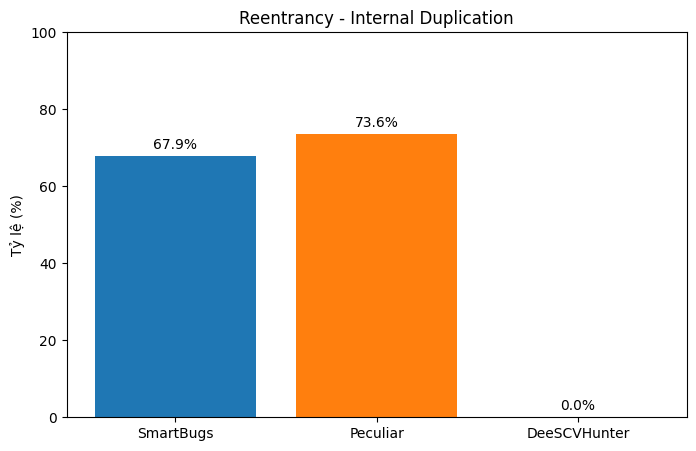

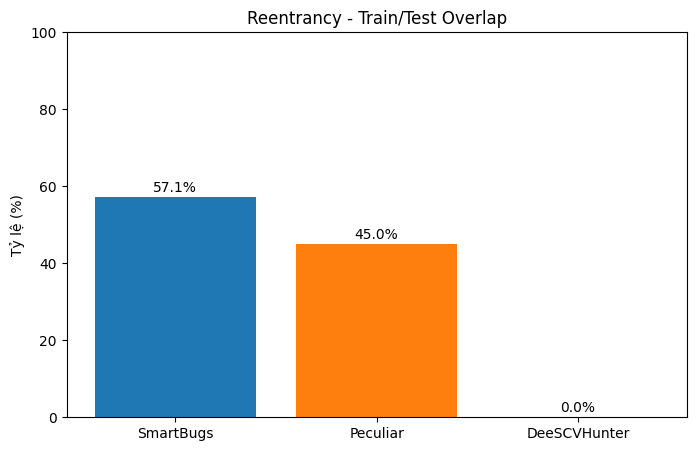

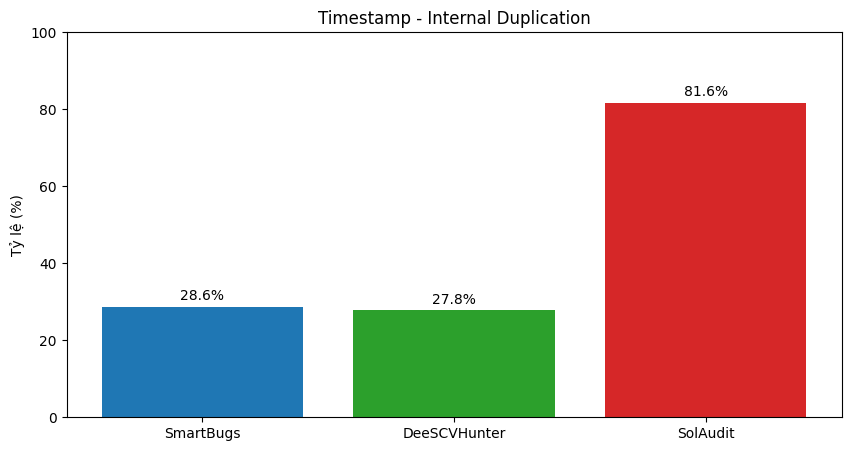

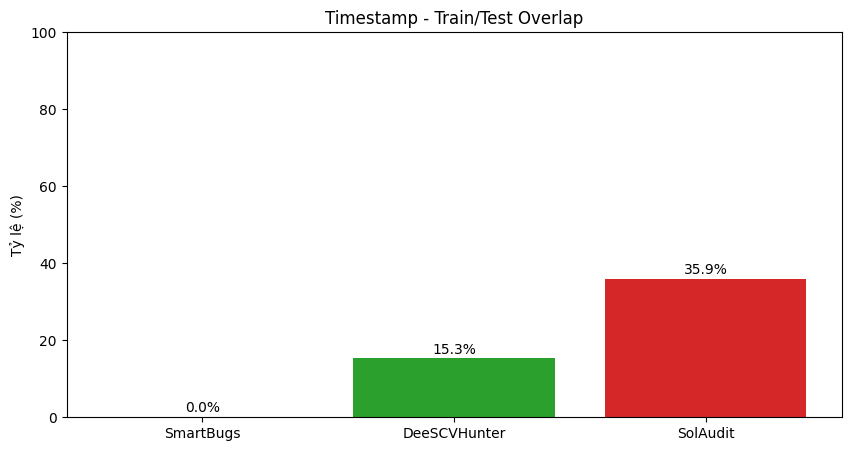

In [ ]:
import matplotlib.pyplot as plt

# 1. Reentrancy - Internal Duplication
plt.figure(figsize=(8, 5))
categories = ['SmartBugs', 'Peculiar', 'DeeSCVHunter']
values = [SmartBugs_ratio[0], peculiar_ratio[0], DeeSCVHunter_ratio[0]]
plt.bar(categories, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Tỷ lệ (%)')
plt.title('Reentrancy - Internal Duplication')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
plt.show()

# 2. Reentrancy - Train/Test Overlap
plt.figure(figsize=(8, 5))
values = [SmartBugs_ratio[1], peculiar_ratio[1], DeeSCVHunter_ratio[1]]
plt.bar(categories, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('Tỷ lệ (%)')
plt.title('Reentrancy - Train/Test Overlap')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')
plt.show()

# 3. Timestamp - Internal Duplication
plt.figure(figsize=(10, 5))
categories = ['SmartBugs', 'DeeSCVHunter', 'SolAudit']
values = [SmartBugs_ratio[2], DeeSCVHunter_ratio[2], soliaudit_ratio[0]]
plt.bar(categories, values, color=['#1f77b4', '#2ca02c', '#d62728'])
plt.ylabel('Tỷ lệ (%)')
plt.title('Timestamp - Internal Duplication')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
plt.show()

# 4. Timestamp - Train/Test Overlap
plt.figure(figsize=(10, 5))
values = [SmartBugs_ratio[3], DeeSCVHunter_ratio[3], soliaudit_ratio[1]]
plt.bar(categories, values, color=['#1f77b4', '#2ca02c', '#d62728'])
plt.ylabel('Tỷ lệ (%)')
plt.title('Timestamp - Train/Test Overlap')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')
plt.show()